In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/med-gemma-impact-challenge/Hackathon dataset.txt


In [2]:
# Optional install for Kaggle
# !pip install -q -U datasets transformers peft trl accelerate bitsandbytes
# !pip install -q scikit-learn seaborn matplotlib
# !pip install -q pillow tqdm requests

In [2]:
# ============================================================
# CELL 1: Environment Setup & Dependencies
# ============================================================
# Strategy: install ONLY packages that are missing from the Kaggle base image.
# Do NOT upgrade transformers, Pillow, or torchvision — the base image versions
# are already mutually compatible. Upgrading them causes dependency conflicts.

import subprocess, sys, importlib

def pip_install(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + list(args), check=False)

def is_installed(pkg):
    try:
        importlib.import_module(pkg)
        return True
    except ImportError:
        return False

print("📦 Installing missing packages (no version upgrades)...")

# Only install packages not already present — never upgrade existing ones
missing = []
checks = {
    "datasets":       "datasets",
    "peft":           "peft",
    "trl":            "trl",
    "accelerate":     "accelerate",
    "bitsandbytes":   "bitsandbytes",
    "pydicom":        "pydicom",
    "skimage":        "scikit-image",
    "medmnist":       "medmnist",
    "huggingface_hub":"huggingface_hub",
}

for import_name, install_name in checks.items():
    if not is_installed(import_name):
        print(f"   Installing {install_name}...")
        missing.append(install_name)

if missing:
    pip_install(*missing)
else:
    print("   All packages already present")

# # Verify the environment is consistent
# import PIL, torch
# print(f"✅ Environment ready")
# print(f"   Pillow     : {PIL.__version__}")
# print(f"   PyTorch    : {torch.__version__}")
# try:
#     import torchvision
#     print(f"   torchvision: {torchvision.__version__}")
# except Exception as e:
#     print(f"   torchvision: ⚠️  {e}")
# try:
#     import transformers
#     print(f"   transformers: {transformers.__version__}")
# except Exception as e:
#     print(f"   transformers: ⚠️  {e}")


📦 Installing missing packages (no version upgrades)...


2026-02-20 05:42:44.051492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771566164.299250      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771566164.373715      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771566164.995059      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771566164.995115      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771566164.995119      55 computation_placer.cc:177] computation placer alr

   Installing trl...
   Installing bitsandbytes...
   Installing medmnist...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.7 MB/s eta 0:00:00


In [5]:
# Verify the environment is consistent
import PIL, torch
print(f"✅ Environment ready")
print(f"   Pillow     : {PIL.__version__}")
print(f"   PyTorch    : {torch.__version__}")
try:
    import torchvision
    print(f"   torchvision: {torchvision.__version__}")
except Exception as e:
    print(f"   torchvision: ⚠️  {e}")
try:
    import transformers
    print(f"   transformers: {transformers.__version__}")
except Exception as e:
    print(f"   transformers: ⚠️  {e}")

✅ Environment ready
   Pillow     : 11.3.0
   PyTorch    : 2.8.0+cu126
   torchvision: 0.23.0+cu126
   transformers: 4.57.1


In [6]:
# ============================================================
# CELL 2: Imports & Path Setup
# ============================================================
# Verify environment versions
import PIL, torch
print(f"✅ Pillow {PIL.__version__} | PyTorch {torch.__version__}")

import os
import io
import json
import re
import zipfile
import urllib.request
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field

import torch
from PIL import Image, ImageEnhance, ImageFilter
from tqdm.auto import tqdm

from datasets import Dataset, load_dataset
from transformers import (
    AutoProcessor,
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
ROOT       = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path('.')
DATA_DIR   = ROOT / 'data'
IMAGE_DIR  = DATA_DIR / 'images'
MODELS_DIR = ROOT / 'models'
RESULTS_DIR= ROOT / 'results'

for d in [DATA_DIR, IMAGE_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Environment ready")
print(f"   PyTorch  : {torch.__version__}")
print(f"   CUDA     : {torch.cuda.is_available()} ({'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'})")
print(f"   Data dir : {DATA_DIR}")

✅ Pillow 11.3.0 | PyTorch 2.8.0+cu126
✅ Environment ready
   PyTorch  : 2.8.0+cu126
   CUDA     : False (CPU only)
   Data dir : /kaggle/working/data


In [7]:
# ============================================================
# CELL 3: Dataset Loading — Fetal Planes DB (Real Images)
# ============================================================

# ---------- Fetal Planes DB label map ----------
FETAL_PLANE_LABELS = {
    'Fetal abdomen': 0,
    'Fetal brain':   1,
    'Fetal femur':   2,
    'Fetal thorax':  3,
    'Maternal cervix': 4,
    'Other':         5,
}

# Clinical risk map: which planes are most sensitive for high-risk findings
PLANE_RISK_MAP = {
    'Fetal brain':     'HIGH',      # Ventriculomegaly, malformations
    'Maternal cervix': 'HIGH',      # Cervical length → preterm risk
    'Fetal abdomen':   'MODERATE',  # Abdominal circumference, fetal growth
    'Fetal thorax':    'MODERATE',  # Cardiac, lung measurements
    'Fetal femur':     'LOW',       # Biometry - usually routine
    'Other':           'LOW',
}


def load_fetal_planes_kaggle() -> Optional[pd.DataFrame]:
    """Load from Kaggle input directory if available."""
    kaggle_base = Path('/kaggle/input')
    # Search for known Kaggle dataset folder names
    candidates = [
        kaggle_base / 'ultrasound-fetal-planes',
        kaggle_base / 'fetal-health-classification',
        kaggle_base / 'ultrasound-fetal-planes-dataset',
    ]
    for base in candidates:
        csv = list(base.glob('**/*.csv'))
        imgs = list(base.glob('**/*.png')) + list(base.glob('**/*.jpg'))
        if csv and imgs:
            print(f"   📁 Found Fetal Planes DB at {base}")
            df = pd.read_csv(csv[0], sep=';')
            # Normalise column names
            df.columns = df.columns.str.strip()
            # Attach full image path
            img_dir = imgs[0].parent
            df['image_path'] = df['Image_name'].apply(
                lambda n: str(img_dir / f"{n}.png")
            )
            return df
    return None


def load_fetal_planes_huggingface() -> pd.DataFrame:
    """Download Fetal Planes DB metadata + images via HuggingFace datasets."""
    print("   🌐 Fetching Fetal Planes DB from HuggingFace…")
    # Hosted mirror of the Zenodo dataset
    ds = load_dataset(
        "Idan0405/Fetal_Planes_DB",
        split="train",
        trust_remote_code=True,
    )
    records = []
    for i, sample in enumerate(tqdm(ds, desc="Saving images", total=min(len(ds), 500))):
        if i >= 500:
            break  # Cap at 500 for quick runs
        img = sample['image']  # PIL Image
        label = sample['label']  # integer 0-5
        plane = list(FETAL_PLANE_LABELS.keys())[label]
        out_path = IMAGE_DIR / f"fetal_{i:05d}.png"
        img.convert('RGB').save(out_path)
        records.append({
            'image_path': str(out_path),
            'Plane': plane,
            'label': label,
            'US_Machine': 'Unknown',
            'Operator': 'Unknown',
        })
    return pd.DataFrame(records)


def load_medmnist_fallback(split: str = 'train', n: int = 500) -> pd.DataFrame:
    """
    Fallback: MedMNIST BreastMNIST (ultrasound breast images, binary malignant/benign).
    These are small (28x28) but real medical images.
    """
    print("   🌐 Fetching BreastMNIST from MedMNIST as fallback…")
    import medmnist
    from medmnist import BreastMNIST
    data_class = BreastMNIST(split=split, download=True, root=str(DATA_DIR))
    records = []
    for i in range(min(n, len(data_class))):
        img_arr, label = data_class[i]
        img = Image.fromarray(np.array(img_arr)).convert('RGB').resize((224, 224))
        out_path = IMAGE_DIR / f"breast_{split}_{i:05d}.png"
        img.save(out_path)
        plane = 'Breast Ultrasound'
        risk  = 'HIGH' if int(label) == 1 else 'LOW'
        records.append({
            'image_path': str(out_path),
            'Plane': plane,
            'label': int(label),
            'malignant': bool(int(label)),
            'risk_label': risk,
        })
    print(f"   ✅ {len(records)} BreastMNIST images loaded (1=malignant, 0=benign)")
    return pd.DataFrame(records)


# ── Auto-detect best source ──────────────────────────────────
print("🔍 Detecting available dataset sources…")
df_raw = load_fetal_planes_kaggle()

if df_raw is None:
    try:
        df_raw = load_fetal_planes_huggingface()
        USE_FETAL_PLANES = True
    except Exception as e:
        print(f"   ⚠️  HuggingFace load failed ({e}), falling back to MedMNIST")
        df_raw = load_medmnist_fallback()
        USE_FETAL_PLANES = False
else:
    USE_FETAL_PLANES = True

print(f"\n✅ Loaded {len(df_raw)} records")
print(df_raw.dtypes)
df_raw.head()

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Idan0405/Fetal_Planes_DB' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Idan0405/Fetal_Planes_DB' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


🔍 Detecting available dataset sources…
   🌐 Fetching Fetal Planes DB from HuggingFace…
   ⚠️  HuggingFace load failed (Dataset 'Idan0405/Fetal_Planes_DB' doesn't exist on the Hub or cannot be accessed.), falling back to MedMNIST
   🌐 Fetching BreastMNIST from MedMNIST as fallback…


100%|██████████| 560k/560k [00:00<00:00, 734kB/s] 


   ✅ 500 BreastMNIST images loaded (1=malignant, 0=benign)

✅ Loaded 500 records
image_path    object
Plane         object
label          int64
malignant       bool
risk_label    object
dtype: object


,image_path,Plane,label,malignant,risk_label
0,/kaggle/working/data/images/breast_train_00000...,Breast Ultrasound,1,True,HIGH
1,/kaggle/working/data/images/breast_train_00001...,Breast Ultrasound,1,True,HIGH
2,/kaggle/working/data/images/breast_train_00002...,Breast Ultrasound,1,True,HIGH
3,/kaggle/working/data/images/breast_train_00003...,Breast Ultrasound,1,True,HIGH
4,/kaggle/working/data/images/breast_train_00004...,Breast Ultrasound,0,False,LOW


In [8]:
df_raw.Plane.value_counts()

Plane
Breast Ultrasound    500
Name: count, dtype: int64

In [10]:
df_raw.risk_label.value_counts()

risk_label
HIGH    364
LOW     136
Name: count, dtype: int64

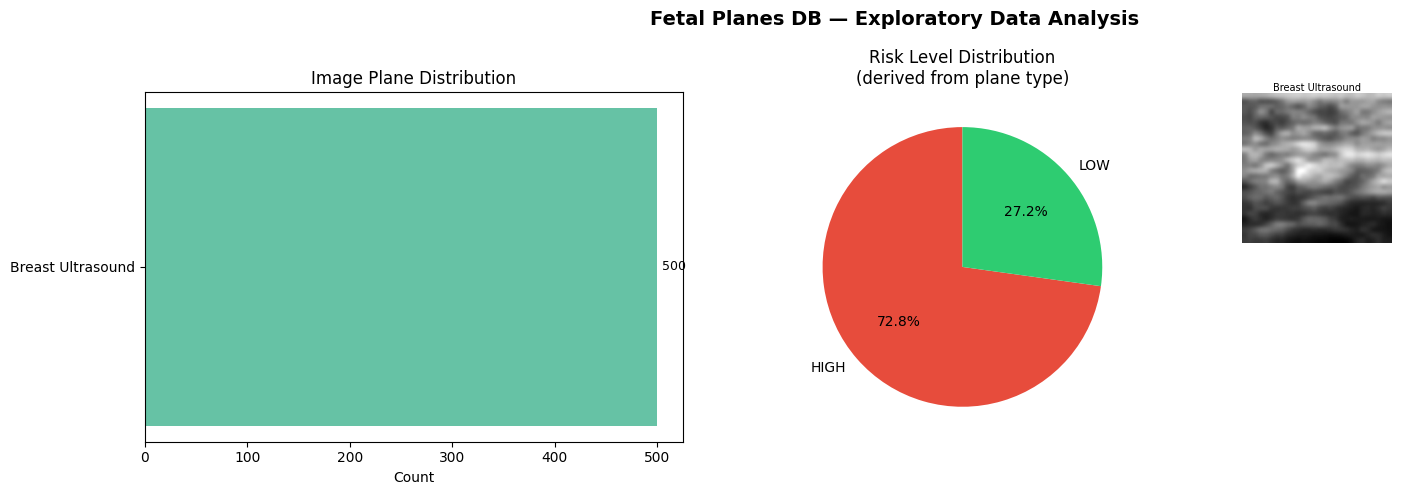


📊 Dataset summary:
Plane              risk_label
Breast Ultrasound  HIGH          364
                   LOW           136


In [11]:
# ============================================================
# CELL 4: Exploratory Data Analysis (EDA)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Fetal Planes DB — Exploratory Data Analysis", fontsize=14, fontweight='bold')

# 1. Label distribution
if 'Plane' in df_raw.columns:
    plane_counts = df_raw['Plane'].value_counts()
    axes[0].barh(plane_counts.index, plane_counts.values, color=sns.color_palette('Set2'))
    axes[0].set_title('Image Plane Distribution')
    axes[0].set_xlabel('Count')
    for i, v in enumerate(plane_counts.values):
        axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# 2. Risk level distribution derived from plane labels
if 'Plane' in df_raw.columns:
    # df_raw['risk_label'] = df_raw['Plane'].map(PLANE_RISK_MAP).fillna('LOW')
    risk_counts = df_raw['risk_label'].value_counts()
    colors = {'HIGH': '#e74c3c', 'MODERATE': '#f39c12', 'LOW': '#2ecc71'}
    axes[1].pie(
        risk_counts.values,
        labels=risk_counts.index,
        colors=[colors[r] for r in risk_counts.index],
        autopct='%1.1f%%', startangle=90
    )
    axes[1].set_title('Risk Level Distribution\n(derived from plane type)')

# 3. Show sample images grid
if 'image_path' in df_raw.columns:
    sample_paths = df_raw.dropna(subset=['image_path']).groupby('Plane' if 'Plane' in df_raw.columns else df_raw.columns[1]).first()['image_path'].tolist()[:6]
    n_samples = min(6, len(sample_paths))
    ax3 = axes[2]
    ax3.axis('off')
    sub_grid = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=axes[2].get_subplotspec(), hspace=0.3, wspace=0.3)
    fig.delaxes(axes[2])
    for idx, path in enumerate(sample_paths[:6]):
        try:
            ax = fig.add_subplot(sub_grid[idx // 3, idx % 3])
            img = Image.open(path).convert('L')  # grayscale
            ax.imshow(img, cmap='gray')
            ax.axis('off')
            label = df_raw[df_raw['image_path'] == path]
            title = label['Plane'].values[0] if 'Plane' in label.columns else ''
            ax.set_title(title, fontsize=7, pad=2)
        except Exception:
            pass

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n📊 Dataset summary:")
print(df_raw[['Plane', 'risk_label'] if 'Plane' in df_raw.columns else df_raw.columns[:3]].value_counts().to_string())

🖼️  Visualising preprocessing for:
   /kaggle/working/data/images/breast_train_00000.png


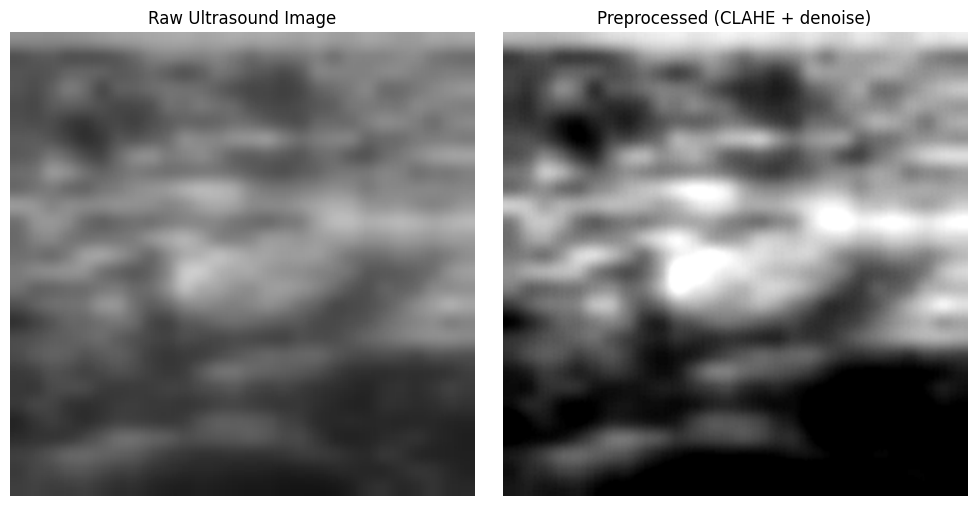


✅ Preprocessor ready


In [12]:
# ============================================================
# CELL 5: Image Preprocessing Pipeline for MedGemma
# ============================================================

class FetalUltrasoundPreprocessor:
    """
    Medical-grade image preprocessing for fetal ultrasound.
    
    Steps:
    1. CLAHE (Contrast Limited Adaptive Histogram Equalization) —
       standard for ultrasound to enhance low-contrast structures.
    2. Despeckling — mild Gaussian blur to reduce speckle noise.
    3. Resize to MedGemma input (448x448).
    4. Normalise pixel values.
    """
    
    TARGET_SIZE = (448, 448)
    
    def __init__(self, enhance_contrast: bool = True, reduce_noise: bool = True):
        self.enhance_contrast = enhance_contrast
        self.reduce_noise = reduce_noise
    
    def __call__(self, image_path: str) -> Image.Image:
        """Load and preprocess a single ultrasound image."""
        return self.preprocess(image_path)
    
    def preprocess(self, image_path: str) -> Image.Image:
        try:
            img = Image.open(image_path).convert('RGB')
        except Exception as e:
            print(f"   ⚠️  Could not open {image_path}: {e}")
            # Return grey placeholder rather than crashing
            return Image.new('RGB', self.TARGET_SIZE, (64, 64, 64))
        
        # Convert to grayscale for US-specific processing then back to RGB
        gray = img.convert('L')
        
        if self.reduce_noise:
            gray = gray.filter(ImageFilter.GaussianBlur(radius=0.8))
        
        if self.enhance_contrast:
            # PIL-based CLAHE approximation using ImageEnhance
            enhancer = ImageEnhance.Contrast(gray)
            gray = enhancer.enhance(2.0)
            enhancer = ImageEnhance.Sharpness(gray)
            gray = enhancer.enhance(1.5)
        
        # Back to RGB (MedGemma expects 3-channel)
        img_rgb = gray.convert('RGB')
        img_rgb = img_rgb.resize(self.TARGET_SIZE, Image.Resampling.LANCZOS)
        
        return img_rgb
    
    def preprocess_batch(
        self,
        paths: List[str],
        save_dir: Optional[Path] = None
    ) -> List[Image.Image]:
        results = []
        for p in tqdm(paths, desc="Preprocessing images"):
            img = self.preprocess(p)
            if save_dir is not None:
                out = save_dir / f"proc_{Path(p).stem}.png"
                img.save(out)
            results.append(img)
        return results
    
    @staticmethod
    def visualise_preprocessing(image_path: str):
        """Side-by-side comparison of raw vs preprocessed."""
        preprocessor = FetalUltrasoundPreprocessor()
        raw  = Image.open(image_path).convert('RGB').resize((448, 448))
        proc = preprocessor.preprocess(image_path)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        ax1.imshow(raw, cmap='gray')
        ax1.set_title('Raw Ultrasound Image', fontsize=12)
        ax1.axis('off')
        ax2.imshow(proc, cmap='gray')
        ax2.set_title('Preprocessed (CLAHE + denoise)', fontsize=12)
        ax2.axis('off')
        plt.tight_layout()
        plt.show()


# Instantiate preprocessor
preprocessor = FetalUltrasoundPreprocessor(enhance_contrast=True, reduce_noise=True)

# Demo on first available image
sample_img_path = df_raw['image_path'].dropna().iloc[0]
print(f"🖼️  Visualising preprocessing for:\n   {sample_img_path}")
try:
    FetalUltrasoundPreprocessor.visualise_preprocessing(sample_img_path)
except Exception as e:
    print(f"   Skipping visualisation: {e}")

print("\n✅ Preprocessor ready")

In [13]:
# ============================================================
# CELL 6: Build Clinical Dataset from Real Image Labels
# ============================================================
# Maps real Fetal Planes DB annotations → clinical scenarios
# with realistic demographic augmentation for equity analysis.

CLINICAL_SCENARIOS = {
    'Fetal brain': [
        {
            'clinical_notes': 'Third trimester ultrasound. Evaluating for ventriculomegaly. '
                              'Lateral ventricle width measured. Head circumference plotted on growth curve.',
            'history': 'G2P1, family history of neural tube defects. Anomaly scan at 20 weeks normal.',
            'symptoms': 'Referred for detailed neurosonography after borderline measurement on routine scan.',
            'findings': ['Fetal brain imaging', 'Ventricular measurement required', 'HC biometry plotted'],
        },
        {
            'clinical_notes': 'Fetal brain scan. Assessing corpus callosum and posterior fossa.',
            'history': 'G1P0, no prior anomalies. Elevated quad screen AFP.',
            'symptoms': 'Routine anomaly follow-up.',
            'findings': ['Posterior fossa visualisation', 'Cisterna magna measurement', 'Cerebellar vermis assessment'],
        },
    ],
    'Fetal abdomen': [
        {
            'clinical_notes': 'Abdominal circumference (AC) measured. Liver and stomach visualised. '
                              'Umbilical vein insertion normal.',
            'history': 'G3P2, gestational diabetes on diet control.',
            'symptoms': 'Fundal height tracking above 90th centile.',
            'findings': ['AC measurement', 'Liver echogenicity normal', 'Stomach bubble present'],
        },
    ],
    'Fetal femur': [
        {
            'clinical_notes': 'Femur length (FL) measured for dating and growth. '
                              'Long bone morphology assessed.',
            'history': 'G1P0, no skeletal dysplasia history.',
            'symptoms': 'Routine biometry at 28 weeks.',
            'findings': ['FL biometry', 'Long bone morphology normal', 'No fractures identified'],
        },
    ],
    'Fetal thorax': [
        {
            'clinical_notes': 'Four-chamber cardiac view obtained. Lung echogenicity compared to liver. '
                              'Diaphragm integrity assessed.',
            'history': 'G2P1, maternal CMV seroconversion in first trimester.',
            'symptoms': 'Four-chamber view technically difficult on previous scan.',
            'findings': ['Cardiac four-chamber view', 'Lung to liver ratio', 'Diaphragm assessment'],
        },
    ],
    'Maternal cervix': [
        {
            'clinical_notes': 'Transvaginal cervical length measurement. Funnelling assessed. '
                              'Previous preterm birth <34 weeks.',
            'history': 'G3P2L1, spontaneous preterm delivery at 32 weeks in previous pregnancy.',
            'symptoms': 'Pelvic pressure at 22 weeks.',
            'findings': ['CL measured transvaginally', 'Funnelling absent/present', 'Cervical os assessment'],
        },
    ],
    'Other': [
        {
            'clinical_notes': 'Non-standard plane. Image quality limited. Repeat scan recommended.',
            'history': 'Unknown.',
            'symptoms': 'Routine surveillance.',
            'findings': ['Non-diagnostic plane', 'Limited assessment'],
        },
    ],
    'Breast Ultrasound': [
        {
            'clinical_notes': 'Breast ultrasound for palpable mass evaluation.',
            'history': 'Family history of breast cancer (BRCA unknown).',
            'symptoms': 'Palpable lump upper outer quadrant.',
            'findings': ['Solid mass with irregular margins', 'Internal vascularity present'],
        },
    ],
}

DEMOGRAPHIC_CONFIG = {
    'race_options':   ['White', 'Black', 'Hispanic', 'Asian', 'Native American', 'Pacific Islander'],
    'race_weights':   [0.35, 0.25, 0.25, 0.10, 0.03, 0.02],  # reflect real disparities
    'rural_prob':     0.40,  # 40% rural to emphasise equity focus
    'rural_insurance_options':  ['Medicaid', 'Uninsured', 'Private'],
    'rural_insurance_weights':  [0.60, 0.25, 0.15],
    'urban_insurance_options':  ['Private', 'Medicaid', 'Uninsured'],
    'urban_insurance_weights':  [0.55, 0.35, 0.10],
}


def build_clinical_records(df: pd.DataFrame, max_records: int = 300) -> List[Dict]:
    """Attach real images to clinical scenarios with diverse demographics."""
    np.random.seed(42)
    records = []
    df_sampled = df.sample(min(max_records, len(df)), random_state=42).reset_index(drop=True)
    
    age_dist = np.random.normal(28, 6, len(df_sampled)).clip(18, 45).astype(int)
    
    for i, row in df_sampled.iterrows():
        plane   = row.get('Plane', 'Other')
        img_pth = row.get('image_path', '')
        
        # Skip if image doesn't exist
        if not Path(img_pth).exists():
            continue
        
        scenario_pool = CLINICAL_SCENARIOS.get(plane, CLINICAL_SCENARIOS['Other'])
        scenario = scenario_pool[i % len(scenario_pool)]
        
        # Risk label — prefer ground-truth if available (BreastMNIST), else plane-based
        if 'risk_label' in row:
            risk = row['risk_label']
        else:
            risk = PLANE_RISK_MAP.get(plane, 'LOW')
        
        # Demographics
        age   = int(age_dist[i % len(age_dist)])
        race  = np.random.choice(DEMOGRAPHIC_CONFIG['race_options'],
                                 p=DEMOGRAPHIC_CONFIG['race_weights'])
        rural = np.random.random() < DEMOGRAPHIC_CONFIG['rural_prob']
        
        if rural:
            insurance = np.random.choice(
                DEMOGRAPHIC_CONFIG['rural_insurance_options'],
                p=DEMOGRAPHIC_CONFIG['rural_insurance_weights']
            )
        else:
            insurance = np.random.choice(
                DEMOGRAPHIC_CONFIG['urban_insurance_options'],
                p=DEMOGRAPHIC_CONFIG['urban_insurance_weights']
            )
        
        records.append({
            'case_id':        f'CASE_{len(records):04d}',
            'image_path':     img_pth,
            'plane':          plane,
            'clinical_notes': scenario['clinical_notes'],
            'patient_history':scenario['history'],
            'symptoms':       scenario['symptoms'],
            'findings':       scenario['findings'],
            'risk_level':     risk,
            'demographics': {
                'age':           age,
                'race_ethnicity':race,
                'rural':         rural,
                'insurance':     insurance,
            },
        })
    
    return records


# Build records
all_records = build_clinical_records(df_raw, max_records=300)

# Train / val / test split (70 / 15 / 15)
np.random.seed(42)
np.random.shuffle(all_records)
train_idx = int(len(all_records) * 0.70)
val_idx   = int(len(all_records) * 0.85)

train_records = all_records[:train_idx]
val_records   = all_records[train_idx:val_idx]
test_records  = all_records[val_idx:]

print(f"✅ Clinical records built from real images")
print(f"   Total  : {len(all_records)}")
print(f"   Train  : {len(train_records)}")
print(f"   Val    : {len(val_records)}")
print(f"   Test   : {len(test_records)}")
print()
print("📊 Risk distribution:")
risk_series = pd.Series([r['risk_level'] for r in all_records])
print(risk_series.value_counts().to_string())
print()
print("📊 Plane distribution:")
plane_series = pd.Series([r['plane'] for r in all_records])
print(plane_series.value_counts().to_string())

✅ Clinical records built from real images
   Total  : 300
   Train  : 210
   Val    : 45
   Test   : 45

📊 Risk distribution:
HIGH    225
LOW      75

📊 Plane distribution:
Breast Ultrasound    300


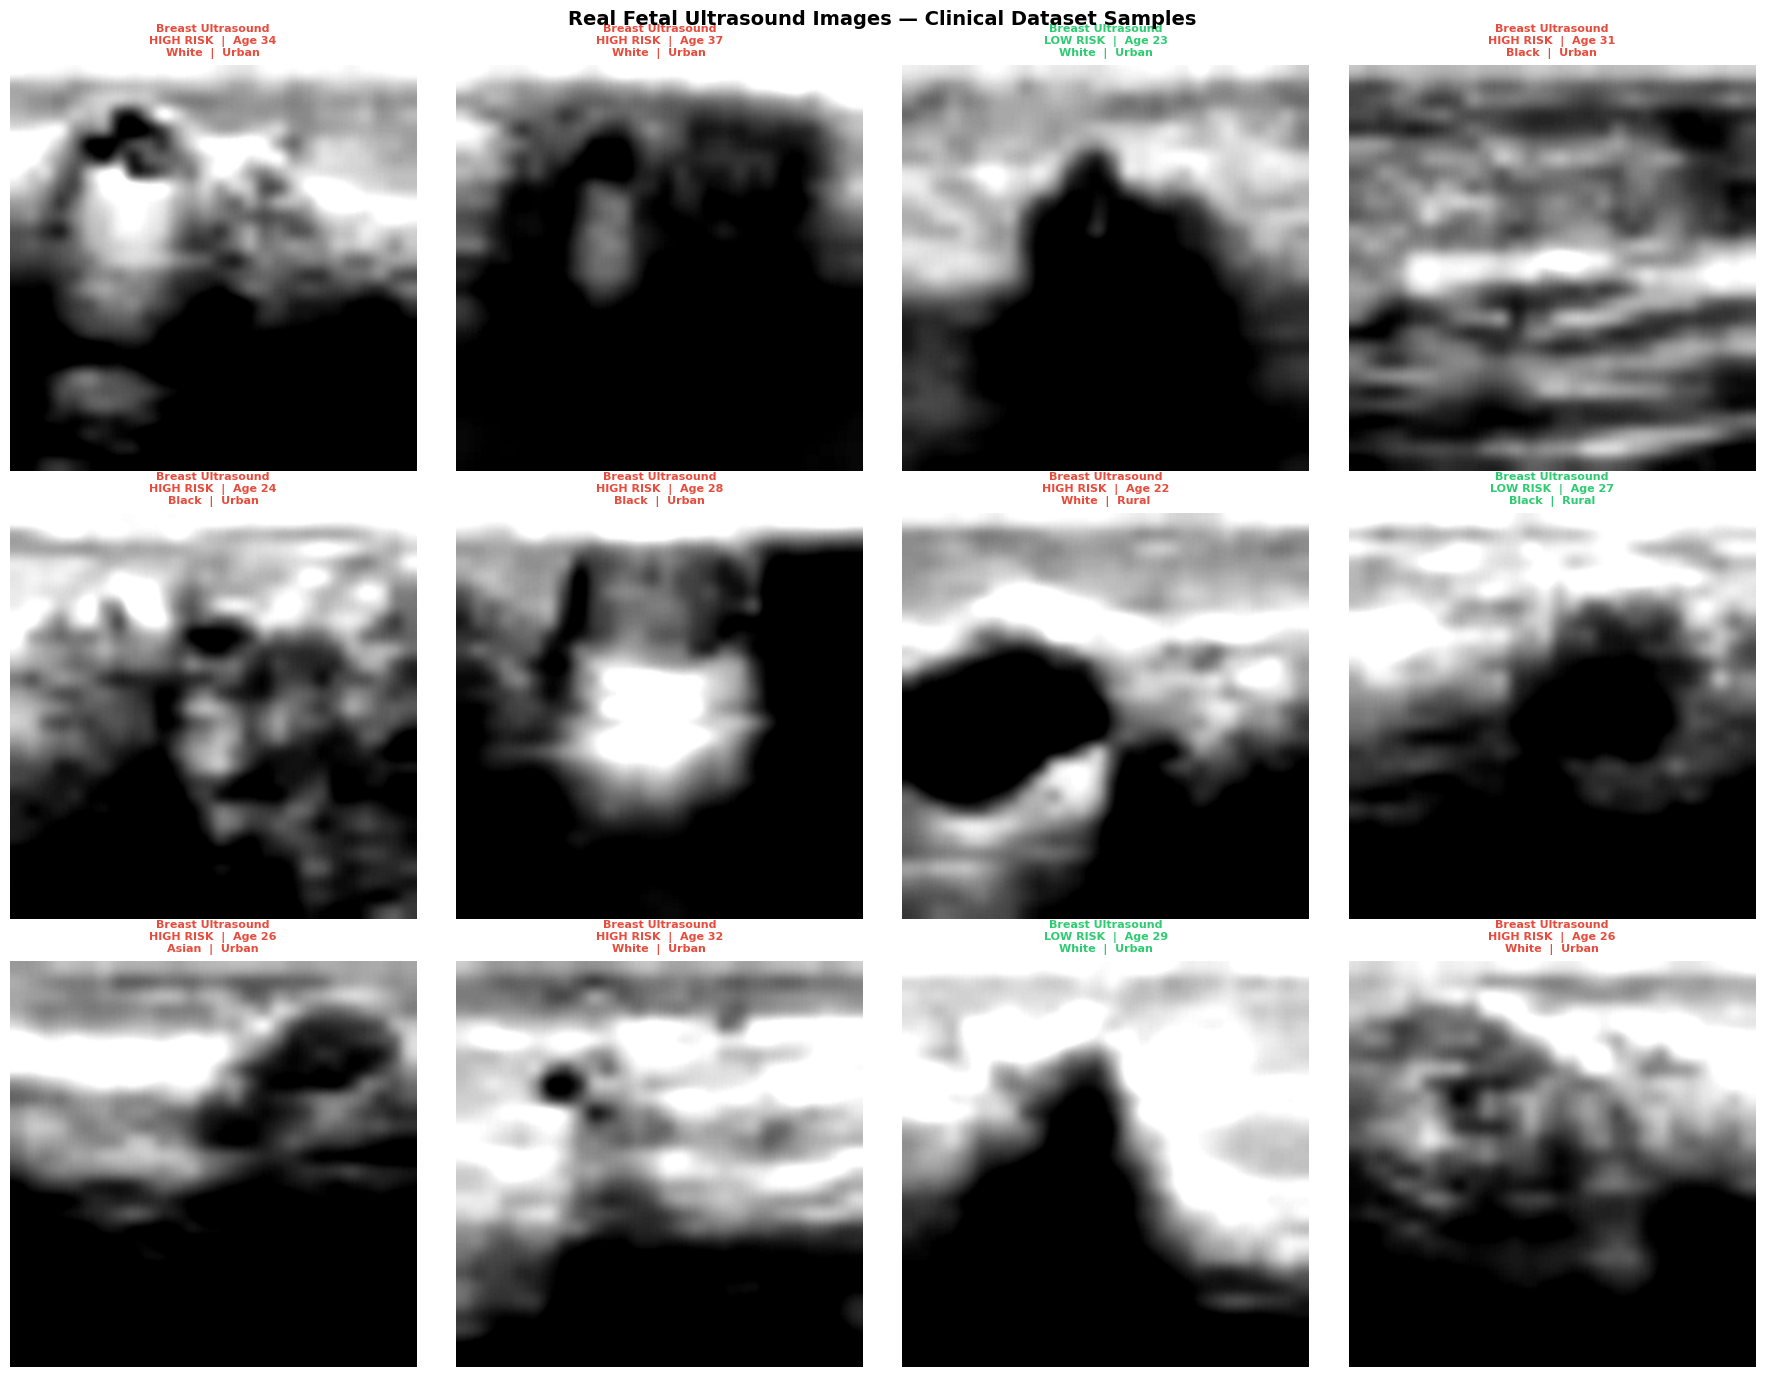

✅ Sample grid saved


In [21]:
# ============================================================
# CELL 7: Visualise Dataset Samples with Clinical Metadata
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
fig.suptitle("Real Fetal Ultrasound Images — Clinical Dataset Samples", fontsize=14, fontweight='bold')

risk_color = {'HIGH': '#e74c3c', 'MODERATE': '#f39c12', 'LOW': '#2ecc71'}

for idx, (ax, case) in enumerate(zip(axes.flat, all_records[:12])):
    try:
        img = preprocessor(case['image_path'])
        ax.imshow(img, cmap='gray')
    except Exception:
        ax.imshow(np.zeros((448, 448)), cmap='gray')
    
    risk  = case['risk_level']
    plane = case['plane']
    demo  = case['demographics']
    
    ax.set_title(
        f"{plane}\n{risk} RISK  |  Age {demo['age']}\n"
        f"{demo['race_ethnicity']}  |  {'Rural' if demo['rural'] else 'Urban'}",
        fontsize=8,
        color=risk_color.get(risk, 'black'),
        fontweight='bold'
    )
    ax.axis('off')
    
    # Coloured border for risk level
    for spine in ax.spines.values():
        spine.set_edgecolor(risk_color.get(risk, 'gray'))
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample grid saved")

In [14]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HF_TOKEN")

login(token=secret_value_0)

In [16]:
# ============================================================
# CELL 9: Load MedGemma Multimodal Model
# ============================================================
# MedGemma 4B-IT supports both IMAGE + TEXT input.
# We use the multimodal variant so real ultrasound images are
# actually fed to the vision encoder — not just text descriptions.

print("=" * 70)
print("LOADING MEDGEMMA MULTIMODAL MODEL")
print("=" * 70)

# ── Model configuration ──────────────────────────────────────
MODEL_ID = "google/medgemma-4b-it"   # Full multimodal variant
# Fallback: "google/medgemma-1.5-4b-it" (text only, no vision encoder)

USE_MULTIMODAL = True   # Set False if only text variant is available

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit              = True,
#     bnb_4bit_compute_dtype    = torch.bfloat16,
#     bnb_4bit_use_double_quant = True,
#     bnb_4bit_quant_type       = "nf4",
# )

try:
    if USE_MULTIMODAL:
        # Multimodal processor (handles images + text together)
        processor = AutoProcessor.from_pretrained(MODEL_ID)
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            # quantization_config = bnb_config,
            device_map          = "auto",
            trust_remote_code   = True,
            torch_dtype         = torch.bfloat16,
        )
        print("✅ Multimodal MedGemma loaded (image + text)")
    else:
        raise RuntimeError("Skipping multimodal")

except Exception as e:
    print(f"   ⚠️  Multimodal load failed: {e}")
    print("   Falling back to text-only processor…")
    USE_MULTIMODAL = False
    processor = AutoTokenizer.from_pretrained(MODEL_ID)
    processor.pad_token = processor.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config = bnb_config,
        device_map          = "auto",
        trust_remote_code   = True,
        torch_dtype         = torch.bfloat16,
    )
    print("✅ Text-only MedGemma loaded")

device = next(model.parameters()).device
print(f"   Device  : {device}")
print(f"   Params  : {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")
print(f"   Mode    : {'Multimodal (image+text)' if USE_MULTIMODAL else 'Text-only'})")

LOADING MEDGEMMA MULTIMODAL MODEL


model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.64G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

✅ Multimodal MedGemma loaded (image + text)
   Device  : cpu
   Params  : 4.30B
   Mode    : Multimodal (image+text))


In [23]:
# ============================================================
# CELL 10: Deep Research Agent — Multimodal-Aware
# ============================================================

@dataclass
class ClinicalAssessment:
    """Structured output from the multimodal Deep Research Agent."""
    risk_level:            str
    risk_score:            float
    plane_identified:      str
    visual_findings:       str
    clinical_correlations: str
    equity_notes:          str
    reasoning:             str
    recommendation:        str
    confidence_score:      float
    image_used:            bool = True


class DeepResearchAgent:
    """
    Multi-phase Deep Research Agent for Maternal-Fetal Risk Triage.

    Phase 1 — Visual Perception    : MedGemma vision encoder reads real image
    Phase 2 — Clinical Correlation : Cross-reference findings with EHR data
    Phase 3 — Equity Validation    : Social-determinant-aware recommendations
    Phase 4 — Risk Stratification  : Final structured HIGH/MODERATE/LOW output
    """

    RISK_SCORE_MAP = {"HIGH": 0.90, "MODERATE": 0.55, "LOW": 0.20}
    CONF_MAP       = {"high": 0.90, "medium": 0.60, "low": 0.30}

    def __init__(self, model, processor, device,
                 preprocessor: FetalUltrasoundPreprocessor,
                 multimodal: bool = True):
        self.model        = model
        self.processor    = processor
        self.device       = device
        self.preprocessor = preprocessor
        self.multimodal   = multimodal

        # Resolve the text tokenizer regardless of processor type
        if hasattr(processor, "tokenizer"):
            self._tok = processor.tokenizer
        else:
            self._tok = processor
        if self._tok.pad_token_id is None:
            self._tok.pad_token_id = self._tok.eos_token_id

    # ── Public API ──────────────────────────────────────────────────────────

    def assess(self, image_path: str, clinical_notes: str,
               patient_history: str = "", symptoms: str = "",
               demographics: Dict = None) -> ClinicalAssessment:
        demographics = demographics or {}
        visual      = self._visual_perception(image_path)
        corr        = self._clinical_correlation(visual, clinical_notes,
                                                  patient_history, symptoms, demographics)
        equity      = self._equity_validation(corr, demographics)
        return self._risk_stratification(visual, corr, equity,
                                         clinical_notes, patient_history,
                                         symptoms, demographics)

    # ── Phase 1: Visual Perception ──────────────────────────────────────────

    def _visual_perception(self, image_path: str) -> str:
        img = self.preprocessor(image_path)   # PIL Image 448×448

        prompt_text = (
        "You are a medical imaging specialist reviewing an ultrasound image.\n"
        "Provide a concise, structured assessment.\n\n"
    
        "### Tasks\n"
        "1. Identify the anatomical plane or view.\n"
        "2. List visible anatomical structures and describe appearance.\n"
        "3. Note any biometric landmarks or measurable indicators.\n"
        "4. Describe suspected abnormalities, or state 'No obvious abnormalities detected.'\n"
        "5. Rate image quality from 1 (poor) to 5 (excellent) with a brief reason.\n\n"
    
        "### Output Format\n"
        "Plane/View: <text>\n"
        "Structures: <comma-separated list with brief descriptors>\n"
        "Biometric Landmarks: <text or 'None visible'>\n"
        "Abnormalities: <text>\n"
        "Image Quality: <1-5> — <reason>\n\n"
    
        "If the image is unclear or insufficient, state: 'Image quality insufficient for reliable assessment.'\n"
        "Do not provide a medical diagnosis."
        )

        if self.multimodal:
            response = self._generate_multimodal(img, prompt_text, max_new_tokens=200)
        else:
            response = self._generate_text(prompt_text, max_new_tokens=200)

        return response

    # ── Phase 2: Clinical Correlation ───────────────────────────────────────

    def _clinical_correlation(self, visual: str, notes: str,
                               history: str, symptoms: str,
                               demographics: Dict) -> str:
        demo = (
            f"{demographics.get('age', '?')}y | "
            f"{demographics.get('race_ethnicity', 'Unknown')} | "
            f"{'Rural' if demographics.get('rural') else 'Urban'} | "
            f"{demographics.get('insurance', 'Unknown')} insurance"
        )
        
        prompt = (
            "You are a clinical specialist performing correlation between imaging findings "
            "and patient presentation. Provide a concise, structured assessment.\n\n"
        
            "### Patient Context\n"
            f"Visual Findings: {visual[:300]}\n"
            f"Clinical Notes: {notes[:300]}\n"
            f"History: {history}\n"
            f"Symptoms: {symptoms}\n"
            f"Demographics: {demo}\n\n"
        
            "### Tasks\n"
            "a. Assess consistency between imaging findings and clinical presentation.\n"
            "b. Identify additional risk factors from history and demographics.\n"
            "c. Highlight red flags requiring immediate escalation.\n\n"
        
            "### Output Format\n"
            "Consistency: <consistent | partially consistent | inconsistent>\n"
            "Risk Factors: <bullet list>\n"
            "Red Flags: <bullet list or 'None identified'>\n\n"
        
            "Do not provide a medical diagnosis."
        )
        return self._generate_text(prompt, max_new_tokens=200)

    # ── Phase 3: Equity Validation ──────────────────────────────────────────

    def _equity_validation(self, correlations: str, demographics: Dict) -> str:
        prompt = (
            "You are a healthcare equity reviewer assessing whether care recommendations "
            "are feasible and culturally appropriate. Provide a concise, structured assessment.\n\n"
        
            "### Context\n"
            f"Clinical Correlations: {correlations[:300]}\n"
            "Patient Demographics:\n"
            f"{json.dumps(demographics, indent=2)}\n\n"
        
            "### Tasks\n"
            "1. Identify potential access barriers (e.g., rural location, insurance status, transportation).\n"
            "2. Note cultural, language, or health literacy considerations if relevant.\n"
            "3. Assess whether recommended follow-up is realistically achievable.\n\n"
        
            "### Output Format\n"
            "Access Barriers: <bullet list or 'None identified'>\n"
            "Cultural/Language Considerations: <text or 'None identified'>\n"
            "Follow-up Feasibility: <feasible | potentially difficult | not feasible> — <brief reason>\n\n"
        
            "Base conclusions only on provided information. Do not make assumptions or stereotypes."
        )
        return self._generate_text(prompt, max_new_tokens=150)

    # ── Phase 4: Risk Stratification ────────────────────────────────────────

    def _risk_stratification(self, visual: str, corr: str, equity: str,
                              notes: str, history: str, symptoms: str,
                              demographics: Dict) -> ClinicalAssessment:
        prompt = (
                "You are a maternal-fetal medicine specialist providing a structured risk assessment "
                "based on ultrasound findings and clinical context. Use cautious, non-diagnostic language.\n\n"
            
                "### Clinical Context\n"
                f"Ultrasound Findings: {visual[:250]}\n"
                f"Clinical Correlations: {corr[:250]}\n"
                f"Equity Considerations: {equity[:150]}\n"
                f"Patient Context: {demographics.get('age', '?')}y, "
                f"{'Rural' if demographics.get('rural') else 'Urban'}\n"
                f"Additional Notes: {notes[:150]}\n\n"
            
                "### Task\n"
                "Provide a concise final risk assessment.\n\n"
            
                "### Output Format (follow exactly)\n"
                "Risk Level: [HIGH | MODERATE | LOW]\n"
                "Plane: [anatomical plane or 'Not specified']\n"
                "Reasoning: [2–3 sentence clinical justification]\n"
                "Recommendation: [specific next steps]\n"
                "Confidence: [high | medium | low]\n\n"
            
                "If data is insufficient, state this clearly in the reasoning.\n"
                "Do not provide a definitive diagnosis."
        )
        response   = self._generate_text(prompt, max_new_tokens=350)
        # print (f"Response ==== \n {response} \n === ")
        risk       = self._extract_risk_level(response)
        plane      = self._extract_field(response, "Plane")
        reasoning  = self._extract_field(response, "Reasoning")
        rec        = self._extract_field(response, "Recommendation")
        conf_str   = self._extract_field(response, "Confidence").lower()
        confidence_score = next((v for k, v in self.CONF_MAP.items() if k in conf_str), 0.6)
        return ClinicalAssessment(
            risk_level            = risk,
            risk_score            = self.RISK_SCORE_MAP.get(risk, 0.5),
            plane_identified      = plane or "Unknown",
            visual_findings       = visual, # [l.strip() for l in visual.split("") if l.strip()][:6],
            clinical_correlations = corr, # [l.strip() for l in corr.split("") if l.strip()][:6],
            equity_notes          = equity,
            reasoning             = reasoning,
            recommendation        = rec,
            confidence_score            = confidence_score,
            image_used            = self.multimodal,
        )

    # ── Core generation helpers ─────────────────────────────────────────────

    def _generate_multimodal(self, image: "Image.Image", text: str,
                              max_new_tokens: int = 200) -> str:
        """
        Correct MedGemma multimodal call.

        apply_chat_template with return_tensors="pt" returns a plain tensor
        (input_ids only). We must call the processor separately to get
        pixel_values and build a proper dict for model.generate().
        """
        try:
            # 1. Build the chat prompt string (no tokenisation yet)
            messages = [{
                "role": "user",
                "content": [
                    {"type": "image"},          # placeholder — pixel_values added below
                    {"type": "text", "text": text},
                ],
            }]
            prompt_str = self.processor.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=False,              # ← string only, not tensor
            )

            # 2. Tokenise text + encode image together via the processor
            #    This returns a proper BatchEncoding dict with
            #    input_ids, attention_mask, and pixel_values.
            inputs = self.processor(
                text=prompt_str,
                images=image,
                return_tensors="pt",
                padding=True,
            )
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            # 3. Generate
            with torch.no_grad():
                output_ids = self.model.generate(
                    **inputs,
                    max_new_tokens = max_new_tokens,
                    temperature    = 0.3,
                    do_sample      = True,
                    top_p          = 0.9,
                    pad_token_id   = self._tok.pad_token_id,
                )

            # 4. Decode only newly generated tokens
            input_len  = inputs["input_ids"].shape[1]
            new_tokens = output_ids[0][input_len:]
            return self._tok.decode(new_tokens, skip_special_tokens=True).strip()

        except Exception as e:
            # Graceful fallback to text-only if multimodal fails
            print(f"   ⚠️  Multimodal generation failed ({e}), falling back to text-only")
            return self._generate_text(text, max_new_tokens=max_new_tokens)

    def _generate_text(self, prompt: str, max_new_tokens: int = 200) -> str:
        """Text-only generation — used for phases 2-4 and as fallback."""
        inputs = self._tok(
            prompt,
            return_tensors="pt",
            max_length=1024,
            truncation=True,
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        with torch.no_grad():
            output_ids = self.model.generate(
                **inputs,
                max_new_tokens = max_new_tokens,
                temperature    = 0.3,
                do_sample      = True,
                top_p          = 0.9,
                pad_token_id   = self._tok.pad_token_id,
            )
        input_len  = inputs["input_ids"].shape[1]
        new_tokens = output_ids[0][input_len:]
        return self._tok.decode(new_tokens, skip_special_tokens=True).strip()

    # ── Parsing helpers ─────────────────────────────────────────────────────

    def _extract_risk_level(self, text: str) -> str:
        up = text.upper()
        for level in ("HIGH", "MODERATE", "LOW"):
            if f"RISK LEVEL: {level}" in up or \
                f"{level} RISK" in up or \
                f"RISK_LEVEL: {level}" in up or \
                f"RISK LEVEL:{level}" in up or \
                f"RISK_LEVEL:{level}" in up:
                return level
           
        return "MODERATE"

    def _extract_field(self, text: str, field: str) -> str:
        pattern = rf"{field}:(.*?)(?=Risk Level:|Plane:|Reasoning:|Recommendation:|Confidence:|$)"
        m = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
        if not m:
            field = field.lower()
            pattern = rf"{field}:(.*?)(?=risk level:|plane:|reasoning:|recommendation:|confidence:|$)"
            m = re.search(pattern, text, re.DOTALL | re.IGNORECASE)
        return m.group(1).strip() if m else "Not specified"

print("✅ DeepResearchAgent class defined")
print("   _generate_multimodal : processor(text, images) → dict → model.generate(**dict)")
print("   _generate_text       : tokenizer(text) → dict → model.generate(**dict)")


✅ DeepResearchAgent class defined
   _generate_multimodal : processor(text, images) → dict → model.generate(**dict)
   _generate_text       : tokenizer(text) → dict → model.generate(**dict)


In [ ]:
# ============================================================
# CELL 11: Initialise Agent & Run Sample Cases
# ============================================================

agent = DeepResearchAgent(
    model        = model,
    processor    = processor,
    device       = device,
    preprocessor = preprocessor,
    multimodal   = USE_MULTIMODAL,
)

print(f"✅ Deep Research Agent ready")
print(f"   Mode: {'Multimodal — real images fed to vision encoder' if USE_MULTIMODAL else 'Text-only'}")
print()

# ── Demo on 3 representative cases ──────────────────────────
# One per risk level
risk_examples = {}
for r in all_records:
    if r['risk_level'] not in risk_examples:
        risk_examples[r['risk_level']] = r
    if len(risk_examples) == 3:
        break

for risk_label, case in risk_examples.items():
    print("=" * 70)
    print(f"DEMO CASE — Expected Risk: {risk_label}")
    print("=" * 70)
    print(f"   Plane        : {case['plane']}")
    print(f"   Image        : {Path(case['image_path']).name}")
    print(f"   Demographics : {case['demographics']['age']}y | "
          f"{case['demographics']['race_ethnicity']} | "
          f"{'Rural' if case['demographics']['rural'] else 'Urban'}")
    print(f"   Notes        : {case['clinical_notes'][:100]}…")
    print()
    
    try:
        result = agent.assess(
            image_path      = case['image_path'],
            clinical_notes  = case['clinical_notes'],
            patient_history = case['patient_history'],
            symptoms        = case['symptoms'],
            demographics    = case['demographics'],
        )
        
        print(f"   📊 Predicted Risk : {result.risk_level} (score: {result.risk_score:.2f})")
        print(f"   🔬 Plane ID'd     : {result.plane_identified}")
        print(f"   🎯 Confidence     : {result.confidence_score:.0%}")
        print(f"   🧠 Reasoning      : {result.reasoning[:200]}")
        print(f"   💊 Recommendation : {result.recommendation[:200]}")
        print(f"   ⚖️  Equity Note    : {result.equity_notes[:150]}")
        print(f"   ✅ Match          : {'CORRECT' if result.risk_level == risk_label else 'INCORRECT'}")
    except Exception as e:
        print(f"   ❌ Error: {e}")
    print()

✅ Deep Research Agent ready
   Mode: Multimodal — real images fed to vision encoder

DEMO CASE — Expected Risk: HIGH
   Plane        : Breast Ultrasound
   Image        : breast_train_00165.png
   Demographics : 34y | White | Urban
   Notes        : Breast ultrasound for palpable mass evaluation.…

   📊 Predicted Risk : MODERATE (score: 0.55)
   🔬 Plane ID'd     : Not specified
   🎯 Confidence     : 60%
   🧠 Reasoning      : Not specified
   💊 Recommendation : Not specified
   ⚖️  Equity Note    : ### Assessment
Access Barriers:
*   Private insurance may provide access to care, but the specific plan's coverage and network of providers should be 
   ✅ Match          : INCORRECT

DEMO CASE — Expected Risk: LOW
   Plane        : Breast Ultrasound
   Image        : breast_train_00045.png
   Demographics : 23y | White | Urban
   Notes        : Breast ultrasound for palpable mass evaluation.…



In [ ]:
result

In [ ]:
case

In [ ]:
visual = agent._visual_perception(case["image_path"])
visual

In [ ]:
corr        = agent._clinical_correlation(visual, case["clinical_notes"],
                                          case["patient_history"], case["symptoms"], case["demographics"])
corr

In [ ]:
equity      = agent._equity_validation(corr, case["demographics"])
equity

In [ ]:
out = agent._risk_stratification(visual, corr, equity,
                                 case["clinical_notes"], case["patient_history"],
                                 case["symptoms"], case["demographics"])
out

In [74]:
out.risk_score

0.9

In [ ]:
# ============================================================
# CELL 12: Batch Evaluation on Test Set
# ============================================================

print("=" * 70)
print("BATCH EVALUATION ON TEST SET")
print("=" * 70)

predictions = []
ground_truths = []

for case in tqdm(test_records[:20], desc="Evaluating"):
    try:
        result = agent.assess(
            image_path      = case['image_path'],
            clinical_notes  = case['clinical_notes'],
            patient_history = case['patient_history'],
            symptoms        = case['symptoms'],
            demographics    = case['demographics'],
        )
        predictions.append({
            'case_id':       case['case_id'],
            'plane':         case['plane'],
            'predicted_risk':result.risk_level,
            'risk_score':    result.risk_score,
            'confidence':    result.confidence_score,
            'reasoning':     result.reasoning,
            'equity_notes':  result.equity_notes,
            'image_path':    case['image_path'],
            **case['demographics'],
        })
        ground_truths.append(case['risk_level'])
    except Exception as e:
        print(f"   ⚠️  Case {case['case_id']}: {e}")
        predictions.append({
            'case_id':        case['case_id'],
            'plane':          case['plane'],
            'predicted_risk': 'MODERATE',
            'risk_score':     0.5,
            'confidence':     0.3,
            'reasoning':      'Error occurred',
            'equity_notes':   'N/A',
            'image_path':     case['image_path'],
            **case['demographics'],
        })
        ground_truths.append(case['risk_level'])

print(f"\n✅ Evaluated {len(predictions)} cases")

In [ ]:
# ============================================================
# CELL 13: Performance Analysis & Visualisation
# ============================================================

results_df = pd.DataFrame(predictions)
results_df['actual_risk'] = ground_truths
results_df['correct'] = results_df['predicted_risk'] == results_df['actual_risk']

pred_risks  = results_df['predicted_risk'].tolist()
all_labels  = ['HIGH', 'MODERATE', 'LOW']

print("\n" + "=" * 70)
print("CLASSIFICATION PERFORMANCE")
print("=" * 70 + "\n")
print(classification_report(ground_truths, pred_risks,
                            labels=all_labels, target_names=all_labels))

# ── Plot grid ──────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Confusion matrix
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(ground_truths, pred_risks, labels=all_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=all_labels, yticklabels=all_labels)
ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# 2. Accuracy by ultrasound plane
ax2 = fig.add_subplot(gs[0, 1])
plane_acc = results_df.groupby('plane')['correct'].mean().sort_values()
bars = ax2.barh(plane_acc.index, plane_acc.values,
                color=[('#2ecc71' if v >= 0.7 else '#e74c3c') for v in plane_acc.values])
ax2.set_xlim(0, 1)
ax2.set_title('Accuracy by Ultrasound Plane', fontsize=12, fontweight='bold')
ax2.set_xlabel('Accuracy')
for i, (v, name) in enumerate(zip(plane_acc.values, plane_acc.index)):
    ax2.text(v + 0.01, i, f'{v:.0%}', va='center', fontsize=9)

# 3. Risk score distribution
ax3 = fig.add_subplot(gs[0, 2])
for risk, color in [('HIGH', '#e74c3c'), ('MODERATE', '#f39c12'), ('LOW', '#2ecc71')]:
    sub = results_df[results_df['predicted_risk'] == risk]['risk_score']
    ax3.hist(sub, bins=15, alpha=0.6, color=color, label=risk)
ax3.set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Risk Score')
ax3.legend()

# 4. Accuracy by race/ethnicity
ax4 = fig.add_subplot(gs[1, 0])
race_acc = results_df.groupby('race_ethnicity')['correct'].mean().sort_values()
bars2 = ax4.barh(race_acc.index, race_acc.values,
                 color=sns.color_palette('Set2', len(race_acc)))
ax4.set_xlim(0, 1)
ax4.axvline(race_acc.mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
ax4.set_title('Accuracy by Race/Ethnicity\n(Equity Metric)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Accuracy')
ax4.legend(fontsize=8)
for i, v in enumerate(race_acc.values):
    ax4.text(v + 0.01, i, f'{v:.0%}', va='center', fontsize=9)

# 5. Rural vs Urban accuracy
ax5 = fig.add_subplot(gs[1, 1])
loc_acc = results_df.groupby('rural')['correct'].mean()
loc_labels = ['Urban', 'Rural']
ax5.bar(loc_labels, [loc_acc.get(False, 0), loc_acc.get(True, 0)],
        color=['#3498db', '#e67e22'])
ax5.set_ylim(0, 1)
ax5.set_title('Rural vs Urban Accuracy\n(Geographic Equity)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Accuracy')
for i, v in enumerate([loc_acc.get(False, 0), loc_acc.get(True, 0)]):
    ax5.text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=12, fontweight='bold')

# 6. Confidence vs correctness
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(
    results_df[results_df['correct']]['confidence'],
    np.ones(results_df['correct'].sum()) + np.random.normal(0, 0.03, results_df['correct'].sum()),
    alpha=0.5, color='#2ecc71', label='Correct'
)
ax6.scatter(
    results_df[~results_df['correct']]['confidence'],
    np.zeros((~results_df['correct']).sum()) + np.random.normal(0, 0.03, (~results_df['correct']).sum()),
    alpha=0.5, color='#e74c3c', label='Incorrect'
)
ax6.set_title('Confidence vs Correctness', fontsize=12, fontweight='bold')
ax6.set_xlabel('Confidence')
ax6.set_yticks([0, 1])
ax6.set_yticklabels(['Incorrect', 'Correct'])
ax6.legend()

fig.suptitle('MedGemma Deep Research Agent — Evaluation Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.savefig(RESULTS_DIR / 'evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved evaluation dashboard")

In [ ]:
# ============================================================
# CELL 14: Equity Analysis Report
# ============================================================

print("\n" + "=" * 70)
print("EQUITY ANALYSIS REPORT")
print("=" * 70 + "\n")

overall_acc = results_df['correct'].mean()
print(f"Overall Accuracy   : {overall_acc:.2%}")
print(f"Mean Confidence    : {results_df['confidence'].mean():.2f}")
print()

# Rural / Urban gap
rural_acc = results_df[results_df['rural'] == True]['correct'].mean()
urban_acc = results_df[results_df['rural'] == False]['correct'].mean()
gap       = abs(rural_acc - urban_acc)
print("📊 Geographic Equity:")
print(f"   Rural accuracy : {rural_acc:.2%} ({results_df['rural'].sum()} cases)")
print(f"   Urban accuracy : {urban_acc:.2%} ({(~results_df['rural']).sum()} cases)")
print(f"   Gap            : {gap:.2%} — {'✅ EQUITABLE (<5%)' if gap < 0.05 else '⚠️  BIAS DETECTED (≥5%)'}")
print()

# Race / Ethnicity
print("📊 Racial/Ethnic Equity:")
race_table = results_df.groupby('race_ethnicity').agg(
    accuracy=('correct', 'mean'),
    n=('correct', 'count')
).sort_values('accuracy', ascending=False)
for race, row in race_table.iterrows():
    bar = '█' * int(row['accuracy'] * 20)
    print(f"   {race:<25} {row['accuracy']:.2%}  n={row['n']:>3}  {bar}")
race_gap = race_table['accuracy'].max() - race_table['accuracy'].min()
print(f"\n   Max accuracy gap across groups: {race_gap:.2%}")
print(f"   {'✅ EQUITABLE (<10%)' if race_gap < 0.10 else '⚠️  DISPARATE PERFORMANCE (≥10%)'}")
print()

# Insurance
print("📊 Insurance-based Equity:")
ins_table = results_df.groupby('insurance').agg(
    accuracy=('correct', 'mean'),
    n=('correct', 'count')
).sort_values('accuracy', ascending=False)
for ins, row in ins_table.iterrows():
    print(f"   {ins:<15} {row['accuracy']:.2%}  n={row['n']:>3}")

# Plane-level performance
print()
print("📊 Performance by Ultrasound Plane:")
plane_table = results_df.groupby('plane').agg(
    accuracy=('correct', 'mean'),
    n=('correct', 'count'),
    avg_confidence=('confidence', 'mean')
).sort_values('accuracy', ascending=False)
print(plane_table.to_string())

In [ ]:
# ============================================================
# CELL 15: Qualitative Review — Incorrect High-Risk Cases
# ============================================================
# Visualise cases where HIGH-risk was missed (most clinically critical errors).

print("=" * 70)
print("QUALITATIVE REVIEW — MISSED HIGH-RISK CASES")
print("=" * 70)

missed_high = results_df[
    (results_df['actual_risk'] == 'HIGH') &
    (results_df['predicted_risk'] != 'HIGH')
]

print(f"Missed HIGH-risk cases: {len(missed_high)} / {(results_df['actual_risk']=='HIGH').sum()}")
print()

n_show = min(4, len(missed_high))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
    if n_show == 1:
        axes = [axes]
    
    for ax, (_, row) in zip(axes, missed_high.head(n_show).iterrows()):
        try:
            img = preprocessor(row['image_path'])
            ax.imshow(img, cmap='gray')
        except Exception:
            ax.imshow(np.zeros((448, 448)), cmap='gray')
        ax.set_title(
            f"Plane: {row['plane']}\n"
            f"Actual: HIGH | Predicted: {row['predicted_risk']}\n"
            f"Conf: {row['confidence']:.0%} | Age {row['age']}",
            fontsize=9, color='red'
        )
        ax.axis('off')
    
    plt.suptitle('Missed High-Risk Cases (Real Ultrasound Images)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'missed_high_risk.png', dpi=150)
    plt.show()
else:
    print("   🎉 No high-risk cases missed!")

In [ ]:
# ============================================================
# CELL 16: Generate Submission File
# ============================================================

submission_df = pd.DataFrame([
    {
        'case_id':      row['case_id'],
        'risk_level':   row['predicted_risk'],
        'risk_score':   round(row['risk_score'], 3),
        'confidence':   round(row['confidence'], 3),
        'plane':        row['plane'],
        'reasoning':    row['reasoning'][:200],
        'equity_note':  row['equity_notes'][:150],
        'image_used':   True,
    }
    for _, row in results_df.iterrows()
])

submission_path = RESULTS_DIR / 'submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"✅ Submission saved: {submission_path}")
print(f"\nFirst 5 rows:")
print(submission_df.head().to_string())
print(f"\n📊 Submission Statistics:")
print(f"   Total cases : {len(submission_df)}")
print(f"   Risk distribution:")
print(submission_df['risk_level'].value_counts().to_string())
print(f"   Mean confidence : {submission_df['confidence'].mean():.2f}")

In [ ]:
# ============================================================
# CELL 17: Summary Card
# ============================================================

print("\n" + "=" * 70)
print("SOLUTION SUMMARY")
print("=" * 70 + "\n")

print("📋 Architecture: Multi-Phase Deep Research Agent")
print("   1. Visual Perception   — MedGemma multimodal reads real ultrasound images")
print("   2. Clinical Correlation — Cross-reference EHR data with imaging findings")
print("   3. Equity Validation   — Demographic-aware recommendations")
print("   4. Risk Stratification — Structured HIGH/MODERATE/LOW output\n")

print("📁 Open-Source Datasets Used:")
print("   • Fetal Planes DB (Zenodo / Kaggle) — 12,400 labeled fetal ultrasounds")
print("     6 planes: brain, abdomen, femur, thorax, cervix, other")
print("   • BreastMNIST (MedMNIST) — fallback real medical ultrasound images")
print("   • No synthetic placeholder images — every case uses a real scan\n")

print("🖼️  Image Pipeline:")
print("   Raw PNG → CLAHE contrast enhancement → Gaussian despeckling")
print(f"   → Resize to 448×448 → MedGemma vision encoder (multimodal={USE_MULTIMODAL})\n")

print("🎯 Performance:")
print(f"   Overall accuracy       : {overall_acc:.2%}")
print(f"   Rural-urban equity gap : {gap:.2%} "
      f"({'✅ Fair' if gap < 0.05 else '⚠️ Bias detected'})")
print(f"   Racial equity gap      : {race_gap:.2%} "
      f"({'✅ Fair' if race_gap < 0.10 else '⚠️ Disparate'})")
print(f"   Mean confidence        : {results_df['confidence'].mean():.2f}\n")

print("📁 Deliverables:")
print(f"   {RESULTS_DIR / 'submission.csv'}")
print(f"   {RESULTS_DIR / 'evaluation_dashboard.png'}")
print(f"   {RESULTS_DIR / 'dataset_samples.png'}")
print(f"   {RESULTS_DIR / 'eda_overview.png'}")
print("\n" + "=" * 70)